# Chapter 21 — Negative Log Loss

Chapter 20 evaluated one prediction by reading the probability assigned to the correct next token.

This chapter converts that probability into a standard numerical penalty called **negative log loss**.

By the end of this chapter, you should be able to:

- compute $-\log(p)$ for a target probability $p$;
- explain why higher target probability gives lower loss;
- reproduce the values for probabilities `1.0`, `0.5`, and `0.01`;
- read and plot the loss curve;
- compare fake model predictions by loss;
- explain why products of probabilities become sums of losses;
- average losses across examples; and
- explain why zero target probability causes an infinite mathematical penalty.

This chapter explains the objective without training a model.


## Turn Target Probability Into a Penalty

For target probability $p$, negative log loss is

$$
L=-\log(p).
$$

Python's `math.log` computes the natural logarithm.

The negative sign makes the loss nonnegative for probabilities between zero and one.


## Why the Direction Reverses

A better prediction gives the correct token more probability.

The logarithm increases with its input, but negating it means larger probability produces smaller loss.

- Higher target probability means lower loss.

- Lower target probability means higher loss.

Training will later minimize this loss, which encourages probability to move toward correct targets.


## Compute the Three Anchor Values

The probabilities `1.0`, `0.5`, and `0.01` make the scale concrete.


In [1]:
import math  # noqa: I001


anchor_probabilities = [1.0, 0.5, 0.01]

print("Target probability | Negative log loss")
print("-" * 43)
for probability in anchor_probabilities:
    loss = -math.log(probability)
    print(f"{probability:>18.2f} | {loss:>17.6f}")

Target probability | Negative log loss
-------------------------------------------
              1.00 |         -0.000000
              0.50 |          0.693147
              0.01 |          4.605170


The results are `0`, approximately `0.69`, and approximately `4.61`.

The model is penalized much more for assigning only one percent probability to the correct token.


## Define a Safe Loss Helper

The helper accepts only target probabilities in the interval $(0,1]$ because zero has no finite logarithm and values above one are not probabilities.


In [2]:
def negative_log_loss(target_probability: float) -> float:
    if target_probability <= 0:
        raise ValueError(
            "target_probability must be greater than 0 because log(0) is not finite."
        )
    if target_probability > 1:
        raise ValueError("target_probability cannot exceed 1.")

    loss = -math.log(target_probability)
    return 0.0 if abs(loss) < 1e-15 else loss


for probability in anchor_probabilities:
    print(f"probability {probability:>5}: loss {negative_log_loss(probability):.6f}")

probability   1.0: loss 0.000000
probability   0.5: loss 0.693147
probability  0.01: loss 4.605170


## Why Probability One Gives Loss Zero

Because $\log(1)=0$, assigning full probability to the observed target gives the minimum one-example loss of zero.

As Chapter 20 emphasized, one perfect observed outcome does not by itself prove that such certainty was justified across many examples.


In [3]:
probability_one_loss = negative_log_loss(1.0)

print("log(1.0):", math.log(1.0))
print("negative log loss:", probability_one_loss)
assert probability_one_loss == 0.0

log(1.0): 0.0
negative log loss: 0.0


## Why Probability One Half Gives About 0.69

A fifty-percent target probability produces $-\log(0.5)\approx0.693$.


In [4]:
half_probability_loss = negative_log_loss(0.5)

print("Loss:", half_probability_loss)
print("Rounded to two decimals:", round(half_probability_loss, 2))
assert round(half_probability_loss, 2) == 0.69

Loss: 0.6931471805599453
Rounded to two decimals: 0.69


## Why Probability 0.01 Gives About 4.61

A one-percent target probability receives a much larger penalty because the model treated the observed outcome as very unlikely.


In [5]:
one_percent_loss = negative_log_loss(0.01)

print("Loss:", one_percent_loss)
print("Rounded to two decimals:", round(one_percent_loss, 2))
assert round(one_percent_loss, 2) == 4.61

Loss: 4.605170185988091
Rounded to two decimals: 4.61


## Inspect More of the Scale

The penalty grows increasingly large as the correct-token probability approaches zero.


In [6]:
probabilities_to_inspect = [
    1.0,
    0.9,
    0.75,
    0.5,
    0.25,
    0.1,
    0.05,
    0.01,
    0.001,
]

print("Target probability | Negative log loss")
print("-" * 43)
for probability in probabilities_to_inspect:
    print(f"{probability:>18.3f} | {negative_log_loss(probability):>17.6f}")

Target probability | Negative log loss
-------------------------------------------
             1.000 |          0.000000
             0.900 |          0.105361
             0.750 |          0.287682
             0.500 |          0.693147
             0.250 |          1.386294
             0.100 |          2.302585
             0.050 |          2.995732
             0.010 |          4.605170
             0.001 |          6.907755


## Plot the Loss Curve

The curve shows both the zero loss at probability one and the sharp penalty near probability zero.


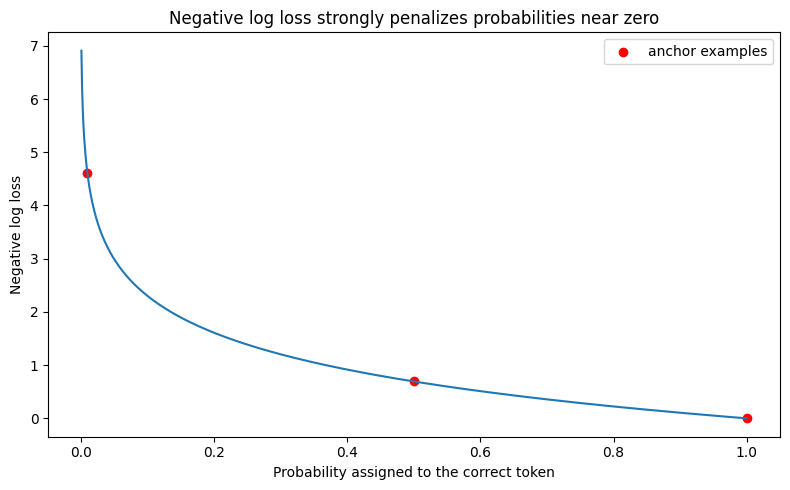

In [7]:
import matplotlib.pyplot as plt  # noqa: I001


probabilities_for_plot = [index / 1000 for index in range(1, 1001)]
losses_for_plot = [
    negative_log_loss(probability) for probability in probabilities_for_plot
]

plt.figure(figsize=(8, 5))
plt.plot(probabilities_for_plot, losses_for_plot)
plt.scatter(
    anchor_probabilities,
    [negative_log_loss(probability) for probability in anchor_probabilities],
    color="red",
    label="anchor examples",
)
plt.xlabel("Probability assigned to the correct token")
plt.ylabel("Negative log loss")
plt.title("Negative log loss strongly penalizes probabilities near zero")
plt.legend()
plt.tight_layout()
plt.show()

The curve is monotonic, so every increase in target probability reduces loss.

Its steepness near zero makes confident mistakes especially costly.


## Compare Two Fake Model Predictions

For the context `"the cat sat on the"`, the observed target is `"mat"`.

Model A assigns `0.60`, while Model B assigns `0.01`.


In [8]:
input_context = "the cat sat on the"
correct_next_token = "mat"
model_a_target_probability = 0.60
model_b_target_probability = 0.01

model_a_loss = negative_log_loss(model_a_target_probability)
model_b_loss = negative_log_loss(model_b_target_probability)

print("Input context:", repr(input_context))
print("Correct next token:", repr(correct_next_token))
print("Model A probability and loss:", model_a_target_probability, model_a_loss)
print("Model B probability and loss:", model_b_target_probability, model_b_loss)
assert model_a_loss < model_b_loss

Input context: 'the cat sat on the'
Correct next token: 'mat'
Model A probability and loss: 0.6 0.5108256237659907
Model B probability and loss: 0.01 4.605170185988091


Model A is better on this example because its higher target probability becomes lower loss.


## Read Loss From a Full Distribution

Real predictions contain one probability per vocabulary token, so evaluation first extracts the target entry and then applies the loss.


In [9]:
vocabulary = ["mat", "rug", "yard", "food", "dog", "cat", "bird", "tree", "."]


def assert_valid_prediction(
    prediction: dict[str, float],
    vocabulary: list[str],
) -> None:
    missing_tokens = set(vocabulary) - set(prediction)
    extra_tokens = set(prediction) - set(vocabulary)
    if missing_tokens or extra_tokens:
        raise ValueError(
            f"Prediction keys do not match the vocabulary. "
            f"Missing: {sorted(missing_tokens)}; extra: {sorted(extra_tokens)}."
        )
    if any(probability < 0 for probability in prediction.values()):
        raise ValueError("Prediction probabilities cannot be negative.")
    if abs(sum(prediction.values()) - 1.0) > 1e-12:
        raise ValueError("Prediction probabilities must sum to 1.")


def prediction_loss(
    prediction: dict[str, float],
    correct_next_token: str,
    vocabulary: list[str],
) -> float:
    assert_valid_prediction(prediction, vocabulary)
    return negative_log_loss(prediction[correct_next_token])

## Evaluate the Two Full Predictions

The distributions match Chapter 20, while their target entries now become losses.


In [10]:
model_a_prediction = {
    "mat": 0.60,
    "rug": 0.25,
    "yard": 0.05,
    "food": 0.02,
    "dog": 0.02,
    "cat": 0.02,
    "bird": 0.01,
    "tree": 0.01,
    ".": 0.02,
}
model_b_prediction = {
    "mat": 0.01,
    "rug": 0.09,
    "yard": 0.30,
    "food": 0.20,
    "dog": 0.15,
    "cat": 0.10,
    "bird": 0.05,
    "tree": 0.05,
    ".": 0.05,
}

model_a_loss = prediction_loss(model_a_prediction, "mat", vocabulary)
model_b_loss = prediction_loss(model_b_prediction, "mat", vocabulary)

print("Model A loss:", model_a_loss)
print("Model B loss:", model_b_loss)
assert model_a_loss < model_b_loss

Model A loss: 0.5108256237659907
Model B loss: 4.605170185988091


## Print a Prediction-Loss Report

The report keeps the context, target, target probability, and transformed loss together.


In [11]:
def print_prediction_loss_report(
    model_name: str,
    input_context: str,
    correct_next_token: str,
    prediction: dict[str, float],
    vocabulary: list[str],
) -> None:
    assert_valid_prediction(prediction, vocabulary)
    probability = prediction[correct_next_token]
    loss = negative_log_loss(probability)
    print("Model:", model_name)
    print("Context:", repr(input_context))
    print("Correct token:", repr(correct_next_token))
    print("Target probability:", probability)
    print("Negative log loss:", loss)


print_prediction_loss_report(
    "Model A",
    input_context,
    correct_next_token,
    model_a_prediction,
    vocabulary,
)
print()
print_prediction_loss_report(
    "Model B",
    input_context,
    correct_next_token,
    model_b_prediction,
    vocabulary,
)

Model: Model A
Context: 'the cat sat on the'
Correct token: 'mat'
Target probability: 0.6
Negative log loss: 0.5108256237659907

Model: Model B
Context: 'the cat sat on the'
Correct token: 'mat'
Target probability: 0.01
Negative log loss: 4.605170185988091


## Why Use a Logarithm

The probability of a sequence under an autoregressive model is a product of its successive correct-token probabilities.

The logarithm turns that product into a sum, and the negative sign turns it into a sum of nonnegative losses.


In [12]:
correct_token_probabilities = [0.5, 0.2, 0.1]
sequence_probability = math.prod(correct_token_probabilities)
loss_from_product = -math.log(sequence_probability)
sum_of_losses = sum(
    negative_log_loss(probability) for probability in correct_token_probabilities
)

print("Token probabilities:", correct_token_probabilities)
print("Sequence probability:", sequence_probability)
print("Negative log of product:", loss_from_product)
print("Sum of token losses:", sum_of_losses)
print("Values match:", abs(loss_from_product - sum_of_losses) < 1e-12)
assert abs(loss_from_product - sum_of_losses) < 1e-12

Token probabilities: [0.5, 0.2, 0.1]
Sequence probability: 0.010000000000000002
Negative log of product: 4.605170185988091
Sum of token losses: 4.605170185988091
Values match: True


Adding losses is easier and more numerically stable than multiplying a long chain of tiny probabilities directly.


## Average Loss Across Examples

A dataset contributes one target probability and one loss per prediction position.

The arithmetic mean makes datasets with different numbers of examples more directly comparable.


In [13]:
from typing import TypedDict  # noqa: I001


class LossExample(TypedDict):
    input_context: str
    correct_next_token: str
    prediction: dict[str, float]


examples: list[LossExample] = [
    {
        "input_context": "the cat sat on the",
        "correct_next_token": "mat",
        "prediction": model_a_prediction,
    },
    {
        "input_context": "the dog ran in the",
        "correct_next_token": "yard",
        "prediction": {
            "mat": 0.05,
            "rug": 0.05,
            "yard": 0.55,
            "food": 0.05,
            "dog": 0.05,
            "cat": 0.05,
            "bird": 0.05,
            "tree": 0.05,
            ".": 0.10,
        },
    },
    {
        "input_context": "the bird sat in the",
        "correct_next_token": "tree",
        "prediction": {
            "mat": 0.05,
            "rug": 0.05,
            "yard": 0.10,
            "food": 0.05,
            "dog": 0.05,
            "cat": 0.05,
            "bird": 0.05,
            "tree": 0.50,
            ".": 0.10,
        },
    },
]


def average_negative_log_loss(
    examples: list[LossExample],
    vocabulary: list[str],
) -> float:
    if not examples:
        raise ValueError("examples cannot be empty.")
    losses = [
        prediction_loss(
            example["prediction"],
            example["correct_next_token"],
            vocabulary,
        )
        for example in examples
    ]
    return sum(losses) / len(losses)


example_losses = [
    prediction_loss(
        example["prediction"],
        example["correct_next_token"],
        vocabulary,
    )
    for example in examples
]

for example_number, (example, loss) in enumerate(
    zip(examples, example_losses, strict=True)
):
    print(
        f"example {example_number}: context {example['input_context']!r}, "
        f"target {example['correct_next_token']!r}, loss {loss:.6f}"
    )

average_loss = average_negative_log_loss(examples, vocabulary)
print("Average negative log loss:", average_loss)

example 0: context 'the cat sat on the', target 'mat', loss 0.510826
example 1: context 'the dog ran in the', target 'yard', loss 0.597837
example 2: context 'the bird sat in the', target 'tree', loss 0.693147
Average negative log loss: 0.6006032683605188


## Plot Individual Contributions

The bar chart shows that average loss combines separate penalties from every target position.


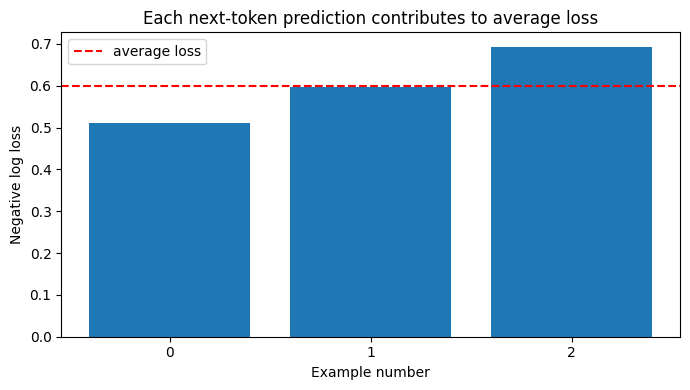

In [14]:
plt.figure(figsize=(7, 4))
plt.bar([str(index) for index in range(len(example_losses))], example_losses)
plt.axhline(
    average_loss,
    color="red",
    linestyle="--",
    label="average loss",
)
plt.xlabel("Example number")
plt.ylabel("Negative log loss")
plt.title("Each next-token prediction contributes to average loss")
plt.legend()
plt.tight_layout()
plt.show()

## Never Evaluate `math.log(0)` Directly

Python raises an error because zero has no finite logarithm.


In [15]:
try:
    math.log(0)
except ValueError as error:
    print("Caught expected error:", error)

try:
    negative_log_loss(0.0)
except ValueError as error:
    print("Caught helper error:", error)

Caught expected error: math domain error
Caught helper error: target_probability must be greater than 0 because log(0) is not finite.


Mathematically, $-\log(p)$ grows without bound as $p$ approaches zero, so zero target probability is described as infinite loss.


## A Zero-Probability Prediction Is Valid but Unevaluable as Finite Loss

The distribution can sum to one while assigning the observed target no chance.


In [16]:
zero_target_prediction = {
    "mat": 0.00,
    "rug": 0.50,
    "yard": 0.20,
    "food": 0.10,
    "dog": 0.05,
    "cat": 0.05,
    "bird": 0.03,
    "tree": 0.02,
    ".": 0.05,
}

assert_valid_prediction(zero_target_prediction, vocabulary)
print("Target probability:", zero_target_prediction["mat"])

try:
    prediction_loss(zero_target_prediction, "mat", vocabulary)
except ValueError as error:
    print("Caught expected error:", error)

Target probability: 0.0
Caught expected error: target_probability must be greater than 0 because log(0) is not finite.


## Smoothing Makes the Penalty Finite

Replacing zero with a small positive probability such as `0.001` still produces a large loss, but the value is finite.


In [17]:
small_smoothed_probability = 0.001
small_smoothed_loss = negative_log_loss(small_smoothed_probability)

print("Target probability:", small_smoothed_probability)
print("Finite loss:", small_smoothed_loss)

Target probability: 0.001
Finite loss: 6.907755278982137


This preserves a strong penalty while allowing arithmetic and averaging to continue.


## Softmax and Stable Neural Losses

In exact mathematics, softmax maps finite scores to strictly positive probabilities that sum to one.

Finite-precision arithmetic can still underflow for extreme score differences, so neural libraries usually combine log-softmax and negative log loss in a numerically stable cross-entropy operation.

The conceptual relationship remains the same: the correct class receives a probability-like score whose negative log is minimized.


## Tiny Probabilities Receive Large Penalties

The loss grows by about `2.30` whenever the target probability becomes ten times smaller because $-\log(0.1)\approx2.30$.


In [18]:
very_small_probabilities = [0.1, 0.01, 0.001, 0.000001]

print("Target probability | Negative log loss")
print("-" * 43)
for probability in very_small_probabilities:
    print(f"{probability:>18.6f} | {negative_log_loss(probability):>17.6f}")

Target probability | Negative log loss
-------------------------------------------
          0.100000 |          2.302585
          0.010000 |          4.605170
          0.001000 |          6.907755
          0.000001 |         13.815511


The scale therefore penalizes confident movement away from the observed target much more than small refinements near high probability.


## Loss Is Not Top-One Accuracy

Accuracy records only whether the largest-probability token equals the target.

Negative log loss retains how much probability the target received, even when another token ranked first.


In [19]:
wrong_top_prediction = {
    "mat": 0.35,
    "rug": 0.40,
    "yard": 0.05,
    "food": 0.03,
    "dog": 0.04,
    "cat": 0.03,
    "bird": 0.03,
    "tree": 0.02,
    ".": 0.05,
}

top_token = max(wrong_top_prediction, key=wrong_top_prediction.__getitem__)
wrong_top_loss = prediction_loss(wrong_top_prediction, "mat", vocabulary)

print("Top token:", repr(top_token))
print("Correct token:", repr("mat"))
print("Correct-token probability:", wrong_top_prediction["mat"])
print("Negative log loss:", wrong_top_loss)

Top token: 'rug'
Correct token: 'mat'
Correct-token probability: 0.35
Negative log loss: 1.0498221244986778


The prediction misses top-one accuracy but receives a much smaller loss than a model assigning the target probability `0.01`.


## Compare With a Linear Penalty

The simple penalty $1-p$ also decreases with target probability, but it does not transform sequence products into sums and penalizes tiny probabilities much less sharply.


In [20]:
print("Probability | 1 - p | Negative log loss")
print("-" * 44)
for probability in [0.9, 0.5, 0.1, 0.01, 0.001]:
    print(
        f"{probability:>11.3f} | {1 - probability:>5.3f} | "
        f"{negative_log_loss(probability):>17.6f}"
    )

Probability | 1 - p | Negative log loss
--------------------------------------------
      0.900 | 0.100 |          0.105361
      0.500 | 0.500 |          0.693147
      0.100 | 0.900 |          2.302585
      0.010 | 0.990 |          4.605170
      0.001 | 0.999 |          6.907755


Negative log loss is also a proper scoring rule, meaning that in expectation it rewards reporting the true probability distribution rather than strategically distorting confidence.


## Complete Loss Pipeline

The final cell validates two predictions, extracts target probabilities, computes losses, and reports the lower-loss model.


In [21]:
final_context = "the cat sat on the"
final_target = "mat"

assert_valid_prediction(model_a_prediction, vocabulary)
assert_valid_prediction(model_b_prediction, vocabulary)

final_a_probability = model_a_prediction[final_target]
final_b_probability = model_b_prediction[final_target]
final_a_loss = negative_log_loss(final_a_probability)
final_b_loss = negative_log_loss(final_b_probability)
final_better_model = "Model A" if final_a_loss < final_b_loss else "Model B"

print("Context:", repr(final_context))
print("Target:", repr(final_target))
print("Model A probability and loss:", final_a_probability, final_a_loss)
print("Model B probability and loss:", final_b_probability, final_b_loss)
print("Lower-loss prediction:", final_better_model)

assert final_better_model == "Model A"

Context: 'the cat sat on the'
Target: 'mat'
Model A probability and loss: 0.6 0.5108256237659907
Model B probability and loss: 0.01 4.605170185988091
Lower-loss prediction: Model A


## Common Mistakes

- Include the negative sign so the loss is nonnegative.

- Pass only probabilities in $(0,1]$ to the scalar helper.

- Minimize loss rather than maximize it.

- Extract the observed target's probability rather than only checking the top token.

- Average token losses when comparing datasets of different lengths.

- Use smoothing or stable neural cross-entropy calculations to avoid explicit `log(0)` failures.

- Keep loss distinct from accuracy and from generated sample quality.


## Takeaways

Negative log loss transforms target probability $p$ into $-\log(p)$.

Probabilities `1.0`, `0.5`, and `0.01` produce losses `0`, approximately `0.69`, and approximately `4.61`.

Lower loss means the model assigned more probability to the correct next token.

Logs turn a product of sequence probabilities into a sum of token losses, which supports stable aggregation and averaging.

Zero target probability has infinite mathematical loss, motivating smoothing and numerically stable neural objectives.

The next chapter applies this loss position by position across whole token sequences and compares average validation loss between models.
